# BVSIMC Demo

Fits BVSIMC on one simulated dataset: hide a fraction of the observed entries, fit on the rest, evaluate against the held-out truth, and check whether the model recovers the correct informative features.

For the full cross-validated benchmark pipeline (grid search, multiple baselines, HPC parallelization), see `scripts/` in the main repo.


## 1. Load data

Uses the dataset saved by `demo_data_generation.ipynb`. Run that notebook first, or regenerate here directly.

In [1]:
import gzip, pickle
import numpy as np

with gzip.open("data/demo_dataset.gz", "rb") as f:
    data = pickle.load(f)

U, V = data["U"], data["V"]
Y_true = data["Y"]          # clean truth
Y_noisy = data["Y_noisy"]   # observed (some positives hidden)

print(f"U: {U.shape}, V: {V.shape}, Y: {Y_true.shape}")


U: (400, 100), V: (600, 100), Y: (400, 600)


## 2. Hold out a test set

Mask a random 10% of entries for evaluation; fit on the rest.

In [2]:
from sklearn.model_selection import train_test_split

rng = np.random.RandomState(0)
rows, cols = np.indices(Y_noisy.shape)
train_idx, test_idx = train_test_split(
    np.arange(Y_noisy.size), test_size=0.1, random_state=0
)

test_row, test_col = rows.flatten()[test_idx], cols.flatten()[test_idx]
test_label = Y_true[test_row, test_col]

Y_train = Y_noisy.copy().flatten()
Y_train[test_idx] = 0            # mask test entries out (treated as unobserved)
Y_train = Y_train.reshape(Y_noisy.shape)

print(f"Train entries: {Y_train.size - len(test_idx)}, test entries: {len(test_idx)}")


Train entries: 216000, test entries: 24000


## 3. Fit BVSIMC

One hyperparameter setting — for tuning guidance see the main repo's grid-search scripts.

In [3]:
from bvsimc import BVSIMC

model = BVSIMC(
    Y=Y_train, U=U, V=V,
    xi=100, eta=1e-4,
    tilde_lambda0=1000, tilde_lambda1=100, tilde_alpha=1 / 25, tilde_beta=1,
    lambda0=1000, lambda1=100, alpha=1 / 25, beta=1,
    K=25, max_iter=1000, tol=1e-5,
)

_, A, B, logLik = model.optimization(seed=0)


Finished with iterations of 999


## 4. Convergence

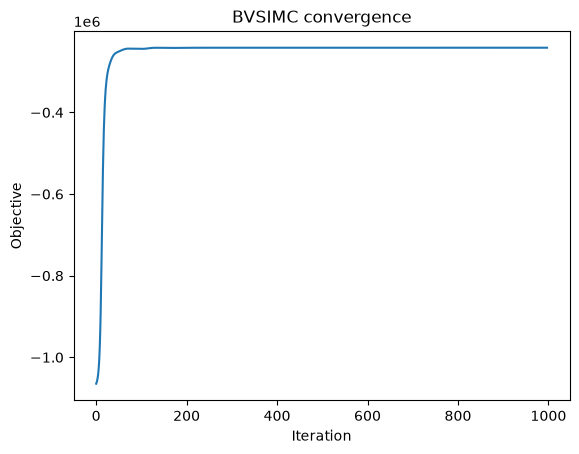

In [4]:
import matplotlib.pyplot as plt

plt.plot(logLik)
plt.xlabel("Iteration")
plt.ylabel("Objective")
plt.title("BVSIMC convergence")
plt.show()


## 5. Evaluate on the held-out entries

In [5]:
from scipy.special import expit
from sklearn.metrics import roc_auc_score, average_precision_score

prob_full = expit((U @ A) @ (V @ B).T)
prob_test = prob_full[test_row, test_col]

auc = roc_auc_score(test_label, prob_test)
aupr = average_precision_score(test_label, prob_test)

print(f"Test AUC:  {auc:.3f}")
print(f"Test AUPR: {aupr:.3f}")


Test AUC:  0.999
Test AUPR: 0.990


## 6. Feature selection

BVSIMC's spike-and-slab prior zeroes out uninformative rows of `A`/`B`. The first 25 features are the true signal — check how many the model recovered.

In [6]:
n_true = 25

selected_A = np.where(np.abs(A).max(axis=1) > 0)[0]
selected_B = np.where(np.abs(B).max(axis=1) > 0)[0]

recall_A = np.isin(np.arange(n_true), selected_A).mean()
recall_B = np.isin(np.arange(n_true), selected_B).mean()

print(f"A: {len(selected_A)} features selected, {recall_A:.0%} of true signal recovered")
print(f"B: {len(selected_B)} features selected, {recall_B:.0%} of true signal recovered")


A: 26 features selected, 100% of true signal recovered
B: 25 features selected, 100% of true signal recovered
